In [1]:
from dataclasses import asdict
from itertools import combinations

import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
if "I__hvgs" not in ds.RNA.feats.columns:
    ds.mark_hvgs(
        min_cells=20,
        top_n=500,
        show_plot=False,
    )
ds.run_normalization(feat_key="hvgs")
pca = ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
)

Downloading bucket files: 31491651 / 31491651 complete

Downloading bytes: 31491651 / 31491651 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 150 / 150 complete

In [2]:
leiden_candidates = {
    0.3: "leiden_r03",
    0.5: "leiden_r05",
    0.8: "leiden_r08",
}
for resolution, label in leiden_candidates.items():
    ds.run_leiden_clustering(
        resolution=resolution,
        label=label,
    )

In [3]:
cluster_sizes = pd.DataFrame(
    {
        label: pd.Series(
            ds.cells.fetch(f"RNA_{label}", key="I")
        ).value_counts()
        for label in leiden_candidates.values()
    }
).fillna(0).astype(int)
cluster_sizes

,leiden_r03,leiden_r05,leiden_r08
1,1320,1275,932
2,913,729,696
3,724,700,652
4,314,314,328
5,274,274,299
6,224,224,284
7,144,224,274
8,15,149,224
9,12,24,146
10,0,15,29


/tmp/ipykernel_4/3576724305.py:13: UserWarning: The figure layout has changed to tight
  leiden_comparison.figure.tight_layout()


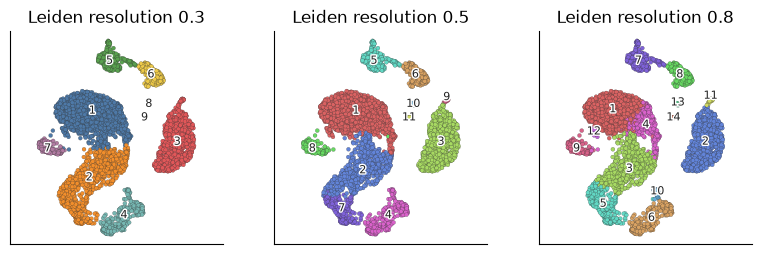

In [4]:
leiden_comparison = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=[f"RNA_{label}" for label in leiden_candidates.values()],
    n_columns=3,
    legend_loc="on_data",
    show_titles=False,
    show=False,
)
for axis, resolution in zip(
    leiden_comparison.axes.values(), leiden_candidates, strict=True
):
    axis.set_title(f"Leiden resolution {resolution}")
leiden_comparison.figure.tight_layout()

In [5]:
agreement_rows = []
for first, second in combinations(leiden_candidates.values(), 2):
    columns = [f"RNA_{first}", f"RNA_{second}"]
    agreement_rows.append(
        {
            "comparison": f"{first} vs {second}",
            "ARI": ds.metric_label_concordance(
                columns,
                metric="ari",
            ),
            "NMI": ds.metric_label_concordance(
                columns,
                metric="nmi",
            ),
        }
    )
pd.DataFrame(agreement_rows)

,comparison,ARI,NMI
0,leiden_r03 vs leiden_r05,0.871895,0.910651
1,leiden_r03 vs leiden_r08,0.714583,0.851471
2,leiden_r05 vs leiden_r08,0.807500,0.904841


In [6]:
silhouette_rows = []
for label in leiden_candidates.values():
    scores = ds.metric_graph_silhouette(res_label=label)
    silhouette_rows.append(
        {
            "partition": label,
            "mean graph silhouette": float(np.nanmean(scores)),
            "minimum graph silhouette": float(np.nanmin(scores)),
        }
    )
pd.DataFrame(silhouette_rows)

Calculating silhouette scores: 9 / 9 complete

Calculating silhouette scores: 11 / 11 complete

Calculating silhouette scores: 14 / 14 complete

,partition,mean graph silhouette,minimum graph silhouette
0,leiden_r03,0.496608,0.146760
1,leiden_r05,0.460662,0.167385
2,leiden_r08,0.416309,0.021973


In [7]:
separability = ds.metric_cluster_separability(
    pca,
    cluster_columns=[
        f"RNA_{label}" for label in leiden_candidates.values()
    ],
)
separability.clustering_scores

,clustering,n_sampled_cells,n_clusters,macro_f1_mean,macro_f1_standard_error,weighted_f1_mean,silhouette_score,status,status_reason
0,RNA_leiden_r03,3940,9,0.974876,0.006229,0.984387,0.373314,scored,None
1,RNA_leiden_r05,3940,11,0.958039,0.007339,0.971741,0.340381,scored,None
2,RNA_leiden_r08,3940,14,0.933759,0.007396,0.959222,0.311341,scored,None


In [8]:
chosen_key = "RNA_leiden_r05"
ds.calc_membership_strength(
    "RNA",
    "I",
    "hvgs",
    chosen_key,
)
membership_key = "RNA_I_cluster_membership_strength"

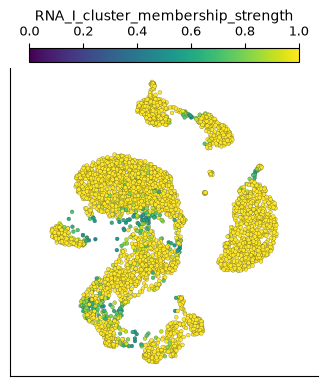

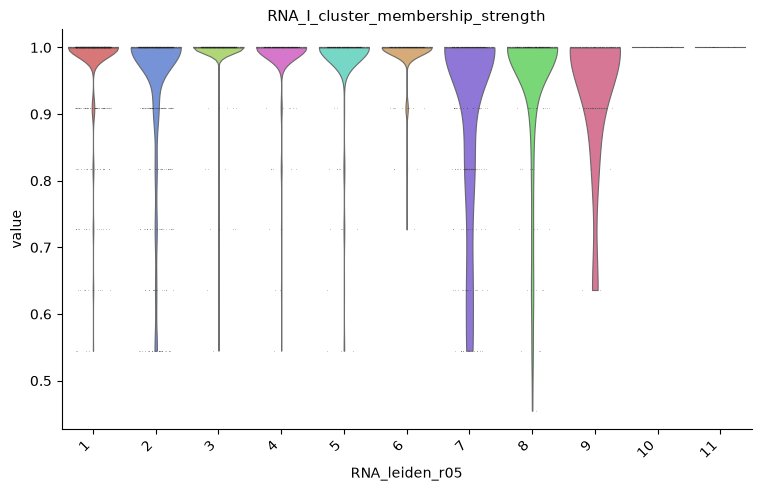

In [9]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=membership_key,
)
ds.plots.distribution(
    keys=membership_key,
    group_by=chosen_key,
    kind="violin",
)

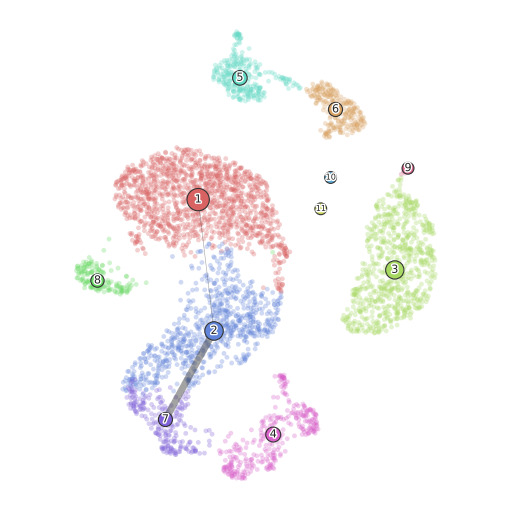

In [10]:
ds.plots.cluster_connectivity(
    group_by=chosen_key,
    layout_key="RNA_UMAP",
    from_assay="RNA",
    feat_key="hvgs",
    show_cells=True,
)

In [11]:
paris_auto = ds.run_paris_clustering(
    n_clusters="auto",
    label="paris_auto",
)
pd.DataFrame(
    [asdict(item) for item in paris_auto.diagnostics]
)[
    [
        "label",
        "size",
        "persistence",
        "decision_margin",
        "forced",
    ]
]

,label,size,persistence,decision_margin,forced
0,1,723,331.653463,0.237157,False
1,2,223,134.439782,0.491158,False
2,3,1275,376.133773,0.160887,False
3,4,306,129.103860,0.171277,False
4,5,523,74.549039,NaN,False
5,6,164,94.722376,0.400639,False
6,7,276,124.722597,0.305551,False
7,8,423,143.850267,0.216814,False
8,9,15,NaN,NaN,True
9,10,12,NaN,NaN,True


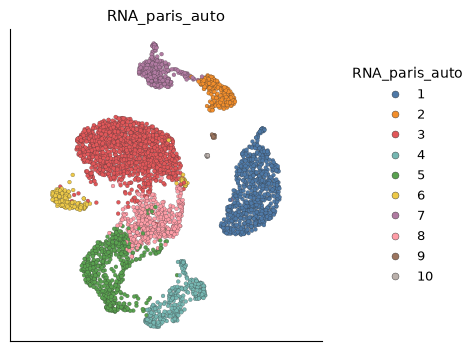

Constructing graph from dendrogram: 3939 / 3939 complete

Identifying the top node for cluster: 1 / 1 complete

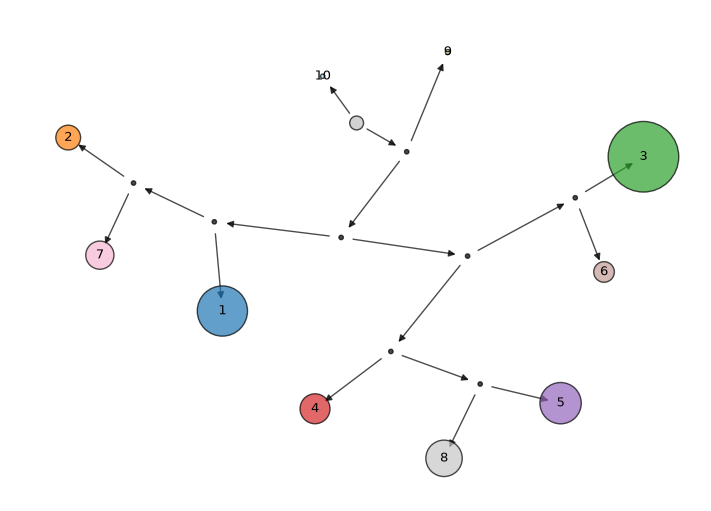

In [12]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=paris_auto.label_key,
)
ds.plots.cluster_tree(
    cluster_key=paris_auto.label_key,
    width=1.7,
    fontsize=9,
    figsize=(7, 5),
)

In [13]:
paris_fixed = ds.run_paris_clustering(
    n_clusters=paris_auto.n_clusters,
    label="paris_fixed",
)
ds.metric_label_concordance(
    [paris_auto.label_key, paris_fixed.label_key],
    metric="ari",
)

1.0

In [14]:
ds.run_marker_search(group_key=chosen_key)
largest_group = pd.Series(
    ds.cells.fetch(chosen_key, key="I")
).value_counts().index[0]
markers = ds.get_markers(
    group_key=chosen_key,
    group_id=largest_group,
)
print(f"Largest group: {largest_group}")
markers[
    [
        "feature_name",
        "score",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(10)

Finding markers: 1 / 1 complete

Largest group: 1


,feature_name,score,auc,p_value,p_value_adjusted
0,ADTRP,0.65290,0.60867,2.286303e-108,1.574085e-106
1,TSHZ2,0.61338,0.64586,2.456065e-135,2.341334e-133
2,CHRM3-AS2,0.53453,0.66861,1.608757e-157,1.975727e-155
3,TCEA3,0.53053,0.59230,4.388088e-80,1.759365e-78
4,CMTM8,0.50302,0.62114,1.434333e-89,7.378425e-88
5,FHIT,0.49172,0.77493,3.454700e-286,1.471702e-283
6,EPHX2,0.45317,0.66474,4.900309e-143,5.099314e-141
7,MAL,0.45204,0.77725,1.889825e-253,5.991186e-251
8,MAN1C1,0.43794,0.62228,9.585216e-86,4.415747e-84
9,CD40LG,0.41705,0.65203,1.264437e-92,6.950325e-91


Computing RNA feature statistics: 102 / 102 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 100 / 100 complete

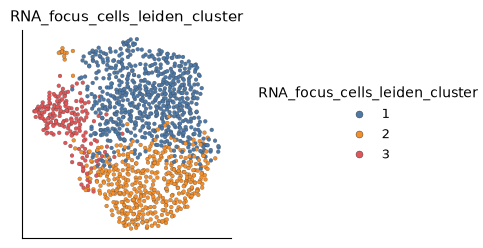

In [15]:
clusters = ds.cells.fetch_all(chosen_key)
active = ds.cells.fetch_all("I").astype(bool)
focus = pd.Series(clusters[active]).value_counts().index[0]
ds.cells.insert(
    "focus_cells",
    active & (clusters == focus),
    overwrite=True,
)
ds.mark_hvgs(
    cell_key="focus_cells",
    min_cells=10,
    top_n=500,
    show_plot=False,
)
ds.run_normalization(
    cell_key="focus_cells",
    feat_key="hvgs",
)
ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_umap(
    cell_key="focus_cells",
    n_epochs=100,
    spread=5,
    min_dist=1,
    parallel=True,
    label="UMAP",
)
ds.run_leiden_clustering(
    cell_key="focus_cells",
    resolution=0.4,
    label="leiden_cluster",
)
ds.plots.embedding(
    layout_key="RNA_focus_cells_UMAP",
    color_by="RNA_focus_cells_leiden_cluster",
    cell_key="focus_cells",
)